In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
from statsmodels.formula.api import ols
# 상관분석을 위한 참조
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

📘 연습문제<br>
father-son 데이터 셋은 아버지와 아들의 키를 조사한 데이터 셋이다. 아버지의 키가 아들의 키에 영향을 주는지 분석하고 결과를 보고하시오.

In [3]:
origin = load_data('father-son')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab12_/father-son.xlsx
[desc] 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)

field    description
-------  -------------------
fheight  아버지의 키(Inches)
sheight  아들의 키(Inches)


===== 데이터 크기 확인 =====
데이터셋 크기: (1078, 2)
열 개수: 2
행 개수: 1078

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB
None


,fheight,sheight
0,65.04851,59.77827
1,63.25094,63.21404
2,64.95532,63.34242
3,65.75250,62.79238
4,61.13723,64.28113


아버지의 키와 아들의 키 간의 탐색적 데이터 분석

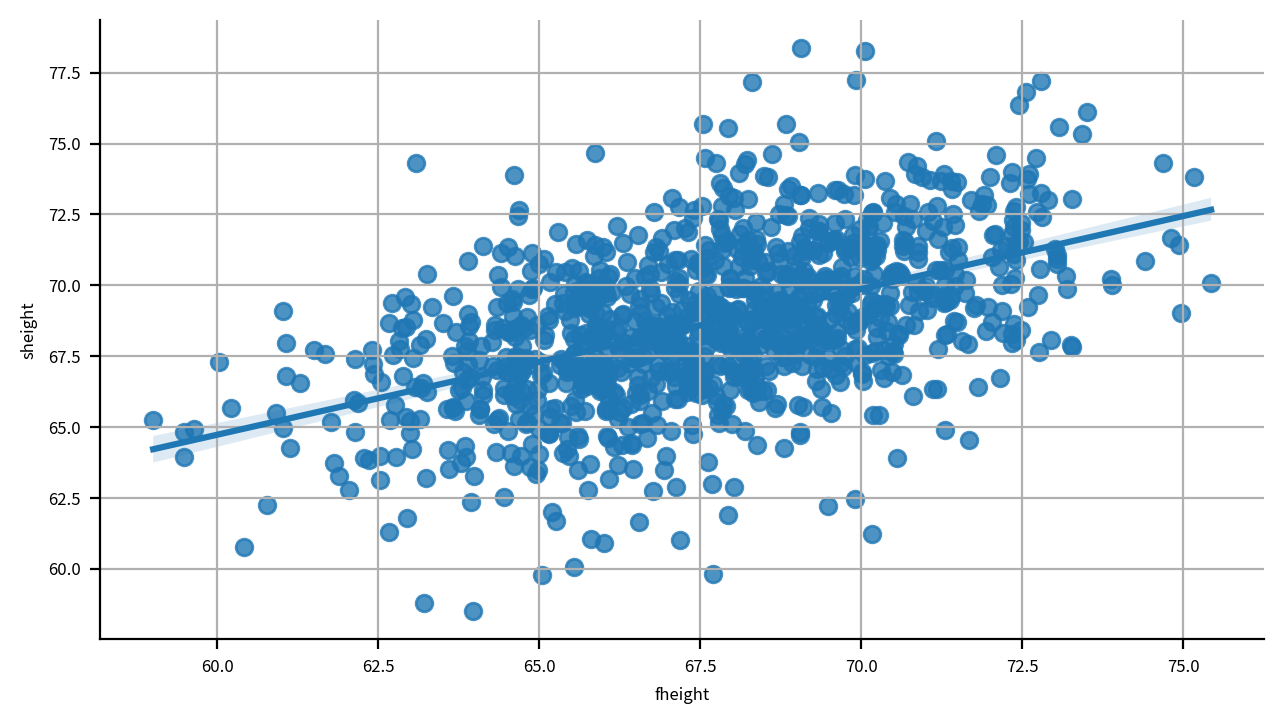

예측이 가능한지
선형성: 충족
상관관계의 강도: 데이터가 회귀선 주변에 꽤 밀집, 하지만 아주 좁게 모여 있진 않음.
이상치: 그래프 상단, 하단에 몇 개 보임. 이런 데이터들은 모델의 예측 성능을 떨어뜨릴 수 있어 주의가 필요함


In [14]:
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# 2) LM Plot 그리기
g = sb.lmplot(data=origin, x="fheight", y="sheight")
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])
plt.grid()
# 3) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료
print(f"예측이 가능한지")
print(
    "선형성: 충족\n"
    "상관관계의 강도: 데이터가 회귀선 주변에 꽤 밀집, 하지만 아주 좁게 모여 있진 않음.\n"
    "이상치: 그래프 상단, 하단에 몇 개 보임. 이런 데이터들은 모델의 예측 성능을 떨어뜨릴 수 있어 주의가 필요함"
)



=== 이상치 확인 ===
이상치 존재


,original_skew,log_skew,outliers(|z|>3)
fheight,-0.088268,-1.155431,1.0
sheight,-0.036696,-1.401806,10.0


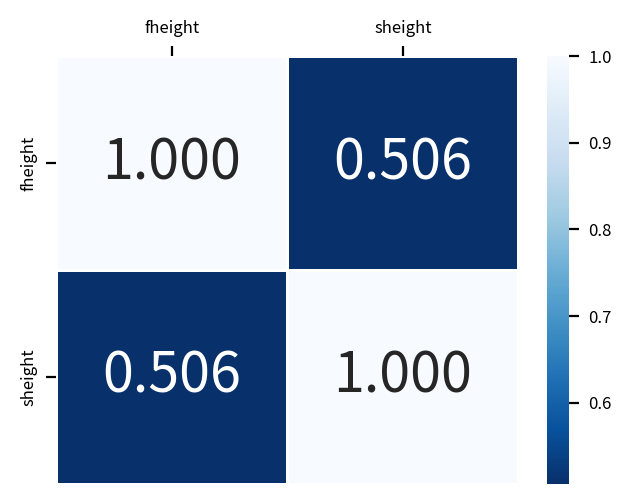

본 분석에서는 fheight과 sheight 간 상관관계를 검토하였다.

데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.

분석 결과, 스피어만 상관계수는 r = 0.506, p = 0.000 (으)로 나타나 두 변수 간 양의 단조 관계가 존재함을 확인하였다.


In [16]:
xname = 'fheight'
yname = 'sheight'

# ---------------------------------
# 선형성 가정 확인 -> 산점도 그래프를 통해 시각적으로 확인
# ---------------------------------
linearity_ok = True  # 선형성 적합 여부 (True=적합, False=부적합)

# ---------------------------------
# 이상치와 왜도 검정
# ---------------------------------
data = origin[[xname, yname]]
results = {}

for col in data.columns:
    temp = data[col].dropna()

    # 왜도 계산
    skew_original = temp.skew()

    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))

    # 로그 변환 후 왜도 계산
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()

    results[col] = {
        'original_skew': skew_original,
        'log_skew': skew_log,
        'outliers(|z|>3)': outlier_count
    }

results_df = DataFrame(results).T

# 이상치 점검 결과
outlier_flag = len(results_df[results_df['outliers(|z|>3)'] > 0]) > 0

print("\n=== 이상치 확인 ===")
print("이상치 존재" if outlier_flag else "이상치 존재하지 않음")
display(results_df)

# ---------------------------------
# 상관분석
# ---------------------------------
report = f"본 분석에서는 {xname}과 {yname} 간 상관관계를 검토하였다.\n\n"

# 1. 상관계수 선택
if linearity_ok and not outlier_flag:
    chosen = 'pearson'
    corr, pval = pearsonr(origin[xname], origin[yname])

    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        report += (
            "데이터 점검 결과, 두 변수의 관계는 선형적이며 이상치의 영향도 크지 않아 "
            "피어슨 상관계수를 사용하였다.\n\n"
            f"분석 결과, 피어슨 상관계수는 r = {corr:0.3f}, p = {pval:0.3f} (으)로 나타나 "
            f"두 변수 간 {'양의 상관' if corr > 0 else '음의 상관'} 관계가 통계적으로 유의함을 확인하였다."
        )

else:
    chosen = 'spearman'
    corr, pval = spearmanr(origin[xname], origin[yname])

    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        report += (
            "데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 "
            "스피어만 상관계수를 사용하였다.\n\n"
            f"분석 결과, 스피어만 상관계수는 r = {corr:0.3f}, p = {pval:0.3f} (으)로 나타나 "
            f"두 변수 간 {'양의 단조' if corr > 0 else '음의 단조'} 관계가 존재함을 확인하였다."
        )

# ---------------------------------
# 결과 시각화
# ---------------------------------
corr_matrix = origin[[xname, yname]].corr(method=chosen)

# 1) 그래프 초기화
width_px = 650
height_px = 500
rows = 1
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) heatmap 그리기
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidths=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20}
)

# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()

# ---------------------------------
# 결과 보고 출력
# ---------------------------------
print(report)

행렬기반 방식<br>
독립변수 행렬 준비<br>
종속변수는 Series 형태로 준비<br>
상수항 추가

회귀분석 수행

"선형 회귀분석"을 추가하여 회귀분석 수행

In [70]:
# ============================================
# 회귀분석 추가 (OLS Regression)
# ============================================
import statsmodels.api as sm

# 1) X, y 구성
X = origin[[xname]]          # 독립변수
y = origin[yname]            # 종속변수

R_squared = model.rsquared
F_statistic = model.fvalue
prob_f = model.f_pvalue

# 2) 상수항 추가
X = sm.add_constant(X)

# 3) 회귀모델 적합
model = sm.OLS(y, X).fit()

# 4) 결과 출력
print("\n\n=== 회귀분석 결과 (OLS Regression) ===\n")
print(model.summary())
print(f"설명력->{R_squared:.4f}이라는 점을 통해, 완벽하게 설명하기엔 부족함이 있다는 결과이다.\n따라서 아버지의 키에 따른 유전적인 영향의 변동성이 약 25.1% 정도 된다는 이야기이다." )
print(f"Prob(F-statistic) = {prob_f:.3e}의 값을 통해 아버지의 키가 아들의 키에 아무 영향을 주지 않는데 우연히 이런 데이터가 나올 확률은 사실상 0%\n나머지 75%는 다른 요인일 가능성이 큼")
print(f"분산 -> {F_statistic:.4f} 의 값을 통해, 사실 자체는 의심할 여지 없이 확실하다.")




=== 회귀분석 결과 (OLS Regression) ===

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                   목, 11 12 2025   Prob (F-statistic):           1.12e-69
Time:                        13:13:33   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33